<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Statistical_Summary%20-%20Bivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Bank Data dataset

First, I will install `scipy` and `pandas` if they are not already installed, then download the `.arff` file from the provided GitHub link. After that, I'll load the dataset into a pandas DataFrame and display its head.

In [1]:
import requests
import pandas as pd
from scipy.io import arff
import io

# Raw GitHub URL for the dataset
github_url = "https://github.com/matteogolfarelli/DataCentricAI/raw/main/bank-data.arff"

# Download the file content
response = requests.get(github_url)
response.raise_for_status() # Raise an exception for HTTP errors

# Load the ARFF data
data, meta = arff.loadarff(io.StringIO(response.text))

# Convert to pandas DataFrame
df = pd.DataFrame(data)

for column in df.select_dtypes(include=['object']).columns:
    df[column] = df[column].apply(lambda x: x.decode('utf-8'))

# Display the first 5 rows of the DataFrame
display(df.head(),df.tail())

,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48.0,FEMALE,INNER_CITY,17546.0,NO,1.0,NO,NO,NO,NO,YES
1,ID12102,40.0,MALE,TOWN,30085.1,YES,3.0,YES,NO,YES,YES,NO
2,ID12103,51.0,FEMALE,INNER_CITY,16575.4,YES,0.0,YES,YES,YES,NO,NO
3,ID12104,23.0,FEMALE,TOWN,20375.4,YES,3.0,NO,NO,YES,NO,NO
4,ID12105,57.0,FEMALE,RURAL,50576.3,YES,0.0,NO,YES,NO,NO,NO


,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
595,ID12696,61.0,FEMALE,INNER_CITY,47025.00,NO,2.0,YES,YES,YES,YES,NO
596,ID12697,30.0,FEMALE,INNER_CITY,9672.25,YES,0.0,YES,YES,YES,NO,NO
597,ID12698,31.0,FEMALE,TOWN,15976.30,YES,0.0,YES,YES,NO,NO,YES
598,ID12699,29.0,MALE,INNER_CITY,14711.80,YES,0.0,NO,YES,NO,YES,NO
599,ID12700,38.0,MALE,TOWN,26671.60,NO,0.0,YES,NO,YES,YES,YES


### Relationship between Age, Income, and PEP (Personal Equity Plan)

This section visualizes the relationship between a customer's age, income, and whether they have a Personal Equity Plan (PEP) using a scatterplot. The plot will help identify any patterns or clusters based on these three variables.

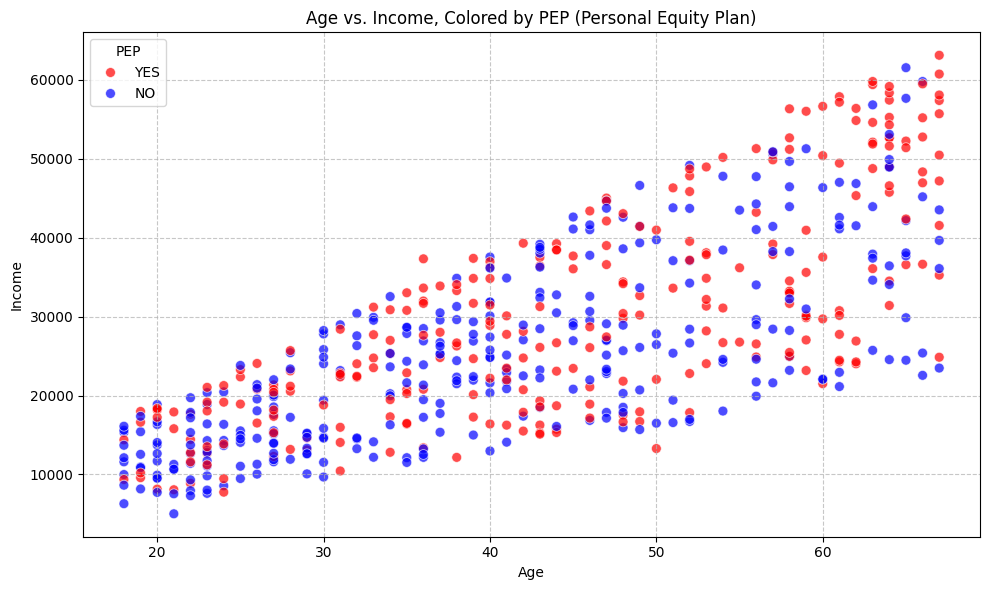

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a custom palette for the 'pep' variable
pep_palette = {'YES': 'red', 'NO': 'blue'}

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='income', hue='pep', palette=pep_palette, s=50, alpha=0.7)
plt.title('Age vs. Income, Colored by PEP (Personal Equity Plan)')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='PEP')
plt.tight_layout()
plt.show()

### Relationship between Number of Children, Income, and PEP (Personal Equity Plan)

This section visualizes the relationship between the number of children, a customer's income, and whether they have a Personal Equity Plan (PEP) using a scatterplot. This plot will help identify any patterns or clusters based on these variables.

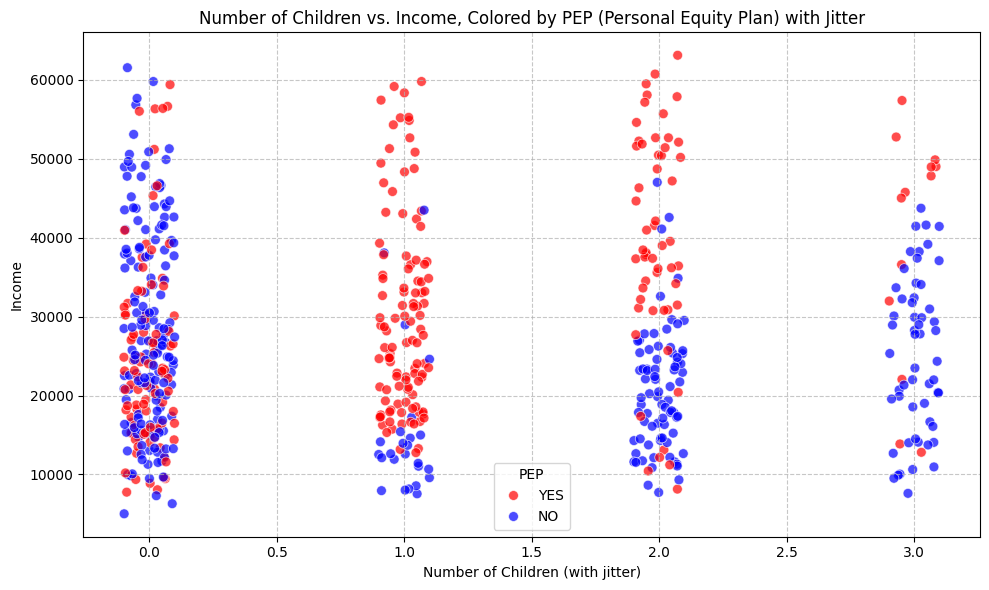

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define a custom palette for the 'pep' variable (already defined, but good to include for self-contained cell)
pep_palette = {'YES': 'red', 'NO': 'blue'}

plt.figure(figsize=(10, 6))
# Add a small amount of jitter to the 'children' variable to better visualize overlapping points
sns.scatterplot(data=df, x=df['children'] + np.random.uniform(-0.1, 0.1, len(df)), y='income', hue='pep', palette=pep_palette, s=50, alpha=0.7)
plt.title('Number of Children vs. Income, Colored by PEP (Personal Equity Plan) with Jitter')
plt.xlabel('Number of Children (with jitter)')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='PEP')
plt.tight_layout()
plt.show()

### Pairplot of All Attributes (excluding 'id'), Colored by PEP

This section generates a scatterplot matrix (pairplot) for all numerical and relevant categorical attributes in the dataset, excluding the unique identifier 'id'. The points in the plots are colored according to the 'pep' variable, allowing for a comprehensive visualization of pairwise relationships and how they vary between customers with and without a Personal Equity Plan.

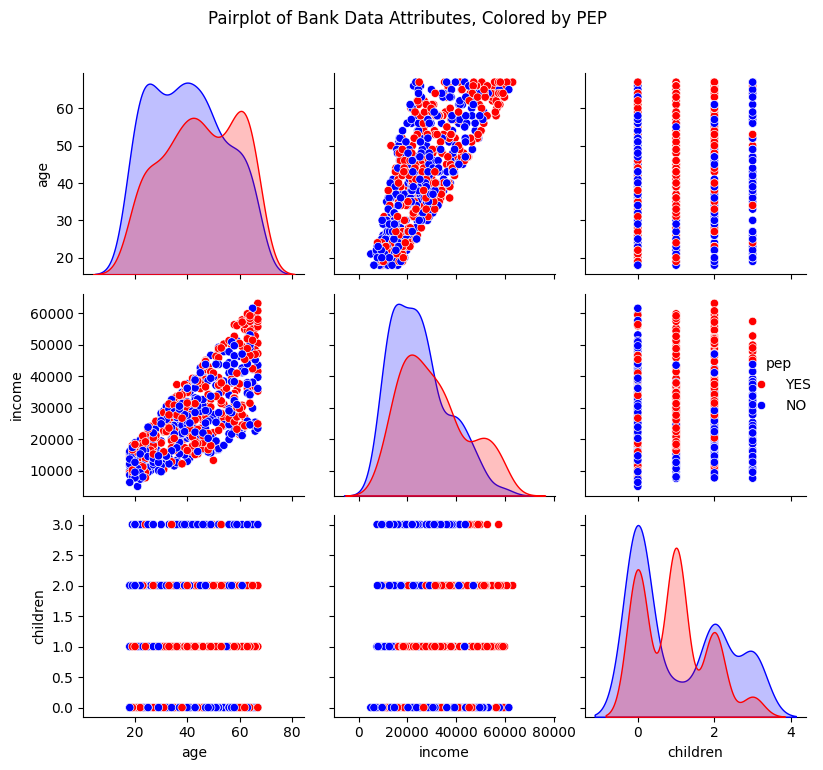

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom palette for 'pep'
pep_palette = {'YES': 'red', 'NO': 'blue'}

# Drop the 'id' column as it's not relevant for a pairplot analysis
df_pairplot = df.drop(columns=['id'])

# Create the pairplot, coloring by 'pep'
sns.pairplot(df_pairplot, hue='pep', palette=pep_palette, diag_kind='kde')
plt.suptitle('Pairplot of Bank Data Attributes, Colored by PEP', y=1.02) # Add a title for the entire figure
plt.tight_layout()
plt.show()

### Matrix of Stacked Bar Charts for Categorical Attributes by PEP

This section visualizes the distribution of each categorical attribute, stacked and colored by the 'pep' variable. This allows for an understanding of how the presence of a Personal Equity Plan (PEP) is distributed across different categories within each feature.

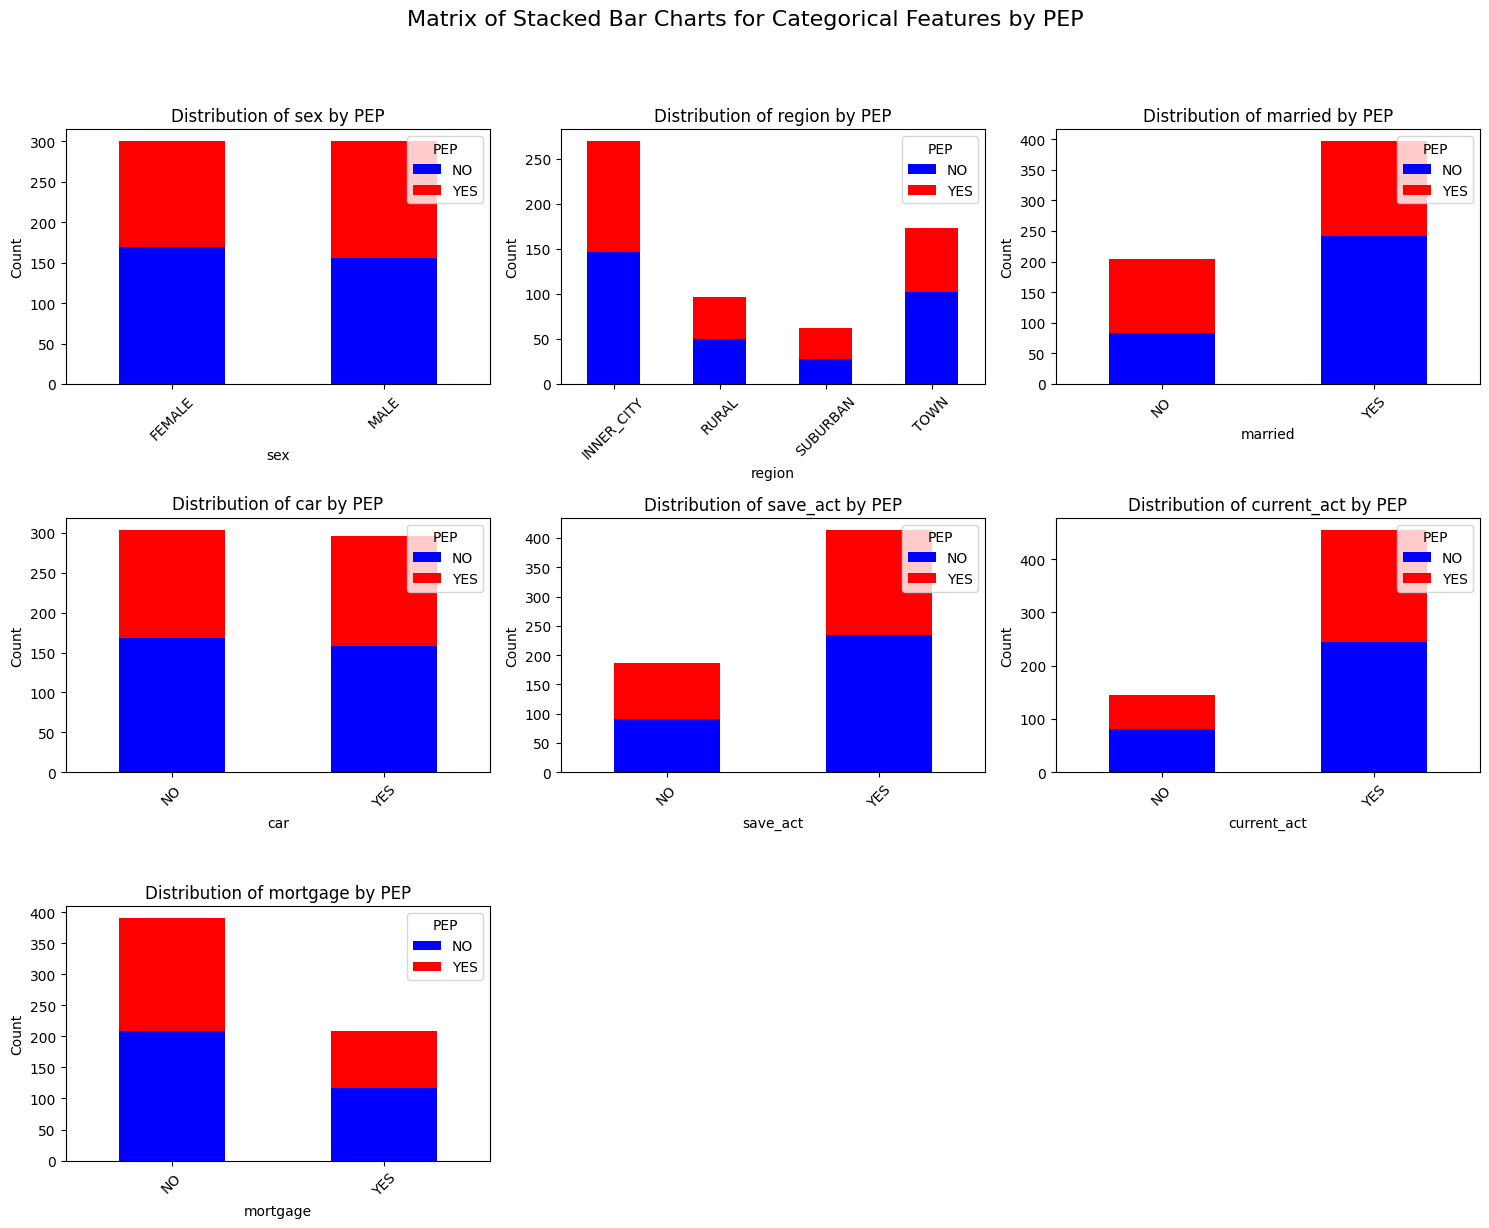

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the custom palette for 'pep'
pep_palette = {'NO': 'blue', 'YES': 'red'} # Define order for consistent stacking

# Identify categorical columns, excluding 'id' and 'pep' itself
categorical_features = [col for col in df.select_dtypes(include=['object']).columns if col not in ['id', 'pep']]

n_features = len(categorical_features)
n_cols_grid = 3 # Number of columns in the subplot grid
n_rows_grid = (n_features + n_cols_grid - 1) // n_cols_grid # Calculate number of rows needed

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))

# Flatten the axes array for easier iteration, handling cases of single row/column grids
if n_rows_grid == 1 and n_cols_grid == 1:
    axes = [axes]
elif n_rows_grid == 1 or n_cols_grid == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax = axes[i]
    # Group by the categorical feature and 'pep', then count
    plot_data = df.groupby([col, 'pep']).size().unstack(fill_value=0)

    # Ensure 'NO' and 'YES' columns exist and are in the correct order for consistent stacking
    ordered_pep_statuses = ['NO', 'YES']
    plot_data = plot_data.reindex(columns=ordered_pep_statuses, fill_value=0)

    # Plotting stacked bars directly using pandas plot
    plot_data.plot(kind='bar', stacked=True, ax=ax, color=[pep_palette[status] for status in ordered_pep_statuses])

    ax.set_title(f'Distribution of {col} by PEP')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='PEP', loc='upper right')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Matrix of Stacked Bar Charts for Categorical Features by PEP', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

### Distribution of Income by Region using Box Plots

This section visualizes the distribution of the 'income' attribute across different 'region' categories using box plots. Box plots are excellent for showing the median, quartiles, and potential outliers in numerical data for each group.

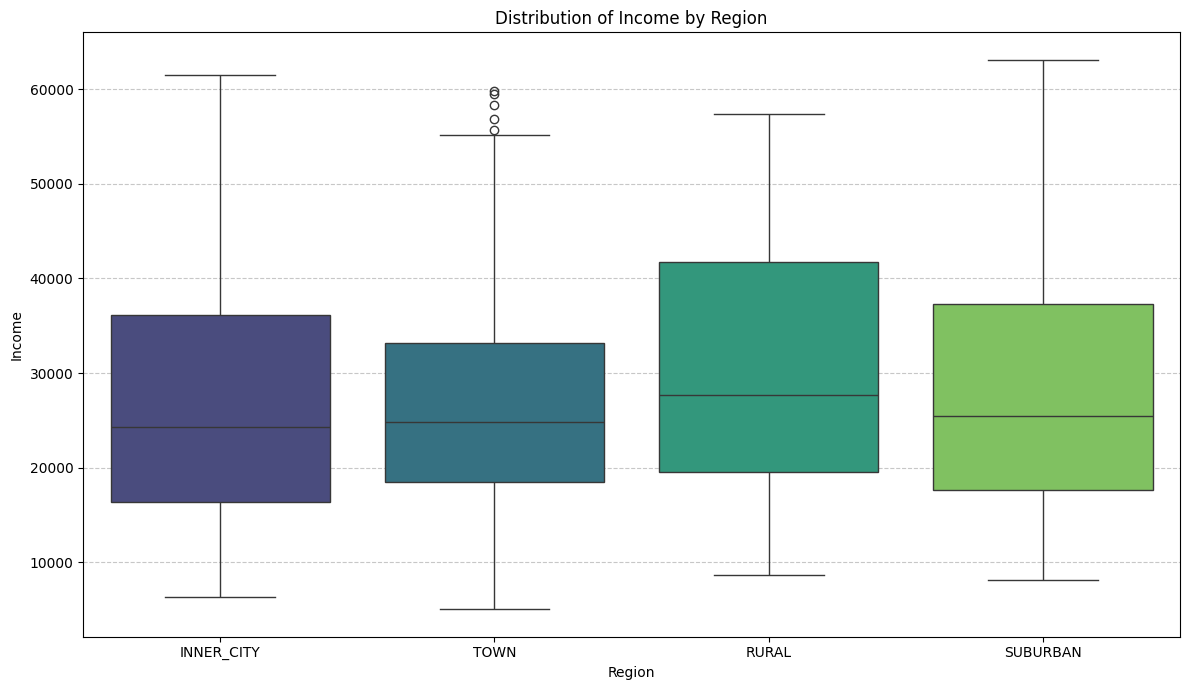

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='region', y='income', hue='region', palette='viridis', legend=False)
plt.title('Distribution of Income by Region')
plt.xlabel('Region')
plt.ylabel('Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Density Plot of Income Distribution by Region

This section uses density plots (Kernel Density Estimates) to visualize the distribution of 'income' for each 'region'. This allows us to see the shape of the distribution, its peaks, and spread across different regions more smoothly than a histogram.

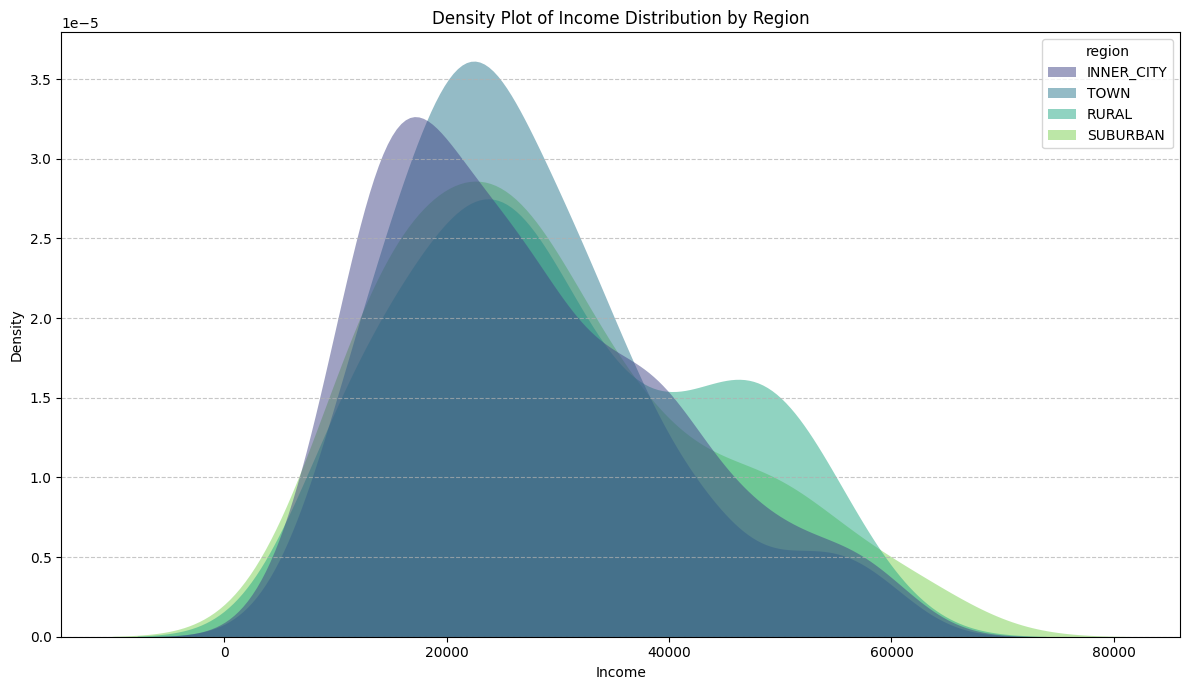

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='income', hue='region', fill=True, common_norm=False, palette='viridis', alpha=0.5, linewidth=0)
plt.title('Density Plot of Income Distribution by Region')
plt.xlabel('Income')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()